# Sentence generator via next-token prediction with transformer

In this tutorial you will get familiar with how to train a model that can generate sentences via the next-token prediction objective.
We will reuse similar code from last exercise, but replace the recurrent neural network (RNN) with a transformer!

We can treat sentence generation as a sequence prediction task.
Formally, let $\mathcal{V}$ be the (finite) set of words (or tokens), including a special end-of-sequence token $\texttt{<EOS>}$.
Without loss of generality, we assume that our dataset $\mathcal{D} = \{ (v^{(n)}_1, v^{(n)}_2, \dots, v^{(n)}_L) \}_{n=1}^N$ is a set of $N$ length-$L$ sentences, where $v_i^{(j)} \in \mathcal{V}$.

For example, some length $6$ sentences can be:
1. $(v_1, v_2, \dots, v_L) = (\text{I}, \text{am}, \text{a}, \text{researcher}, \texttt{<EOS>}, \texttt{<EOS>})$
2. $(v_1, v_2, \dots, v_L) = (\text{Mary}, \text{is}, \text{a}, \text{cool}, \text{person}, \texttt{<EOS>})$

Naturally, the $N$ sentences are i.i.d. samples from an unknown distribution $\mathbb{P}(V_1, \dots, V_L)$.
Our goal is to learn a model $f$ that approximates $\mathbb{P}$ using $\mathcal{D}$.

We make the following decomposition on the model $f$:
$$
f(V_1, V_2, \dots, V_L) = \prod_{\ell=1}^{L} f(V_\ell | V_{< \ell}).
$$
Due to the discrete nature of language, we can treat $f(V_\ell | V_{< \ell})$ as a categorical distribution over the words $\mathcal{V}$.
Then, we can approximate $\mathbb{P}$ by minimizing the Kullback-Leibler (KL) divergence between the two sequences that results in the next-token prediction objective:
$$
\arg\min_{f} \mathbb{E}_{(v_1, \dots, v_L) \sim \mathbb{P}} \left[ \text{KL}(f(v_1, \dots, v_L) || \mathbb{P}(v_1, \dots, v_L)) \right]\\
= \arg\min_{f} \mathbb{E}_{(v_1, \dots, v_L) \sim \mathbb{P}} \left[ \sum_{\ell = 1}^L \log f(v_\ell | v_{< \ell}) \right].
$$
Here, the next-token prediction objective is indicating that we minimize the cross-entropy loss of the current token ($v_\ell$) given the previous tokens ($v_{< \ell}$).  
NOTE: You should work this objective out! You just need to assume that the distributions are categorical, and that the distribution follows the decomposition above. This is equivalent to maximum likelihood (or minimizing negative log likelihood).


What does this really mean in practice?
- In this tutorial, we assume that $f$ is a transformer.
- We index each word (token) $v \in \mathcal{V}$ with a "class ID"---from this perspective, really we just have a classification problem!
  - NOTE: We can completely formulate this differently by treating each sentence as an element of the output space instead, at the cost of blowing the cardinality up exponentially!

### Credits
Bryan Chan, Sept. 2025  

In [1]:
%matplotlib inline
from IPython.display import display, clear_output
import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

"""
These are hyperparameters
XXX: Since a model must take in a token to predict,
     at the first step we feed in start-of-sentence token <SOS> to predict v_1.
"""
SOS_TOKEN = 0 
EOS_TOKEN = 1
MAX_LENGTH = 10

### Construct a transformer (GPT-2 style)

In [2]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding from Vaswani et al. (2017).
    Implementation from: https://stackoverflow.com/questions/77444485/using-positional-encoding-in-pytorch
    Reference: Vaswani et al. (2017) https://arxiv.org/pdf/1706.03762
    """
    def __init__(self, embed_dim: int, dropout: float = 0.1, max_len: int = 10):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim))
        pe = torch.zeros(1, max_len, embed_dim)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


class GPTBlock(nn.Module):
    """ A GPT-style block. """
    def __init__(self, embed_dim, num_heads, widening_factor, dropout_p=0.1):
        super(GPTBlock, self).__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            dropout_p,
            batch_first=True,
        )
        self.ln_1 = nn.LayerNorm(embed_dim)
        self.ln_2 = nn.LayerNorm(embed_dim)
        self.dense_1 = nn.Linear(embed_dim, embed_dim * widening_factor)
        self.dense_2 = nn.Linear(embed_dim * widening_factor, embed_dim)
        self.gelu = nn.GELU()

    def forward(self, input):
        normed_input = self.ln_1(input)
        mask = nn.Transformer.generate_square_subsequent_mask(
            sz=input.shape[1],
            device=input.device,
        )
        att_out, attn = self.attention(
            normed_input,
            normed_input,
            normed_input,
            is_causal=True,
            attn_mask=mask,
        )
        input = att_out + input
        normed_input = self.gelu(self.dense_1(self.ln_2(input)))
        out = input + self.dense_2(normed_input)
        return out, attn
    

class DecoderTransformer(nn.Module):
    """
    A transformer decoder.
    """
    def __init__(
        self,
        output_size,
        num_blocks,
        embed_dim,
        num_heads,
        widening_factor=4,
        dropout_p=0.1,
        max_len=MAX_LENGTH,
    ):
        super(DecoderTransformer, self).__init__()

        self.embedding = nn.Embedding(output_size, embed_dim)
        self.pe = PositionalEncoding(embed_dim, dropout_p, max_len)
        gpt_blocks = []
        ln_layers = []
        for block_i in range(num_blocks):
            gpt_blocks.append(
                GPTBlock(embed_dim, num_heads, widening_factor, dropout_p)
            )
            ln_layers.append(
                nn.LayerNorm(embed_dim)
            )
        self.gpt_blocks = nn.ModuleList(gpt_blocks)
        self.ln_layers = nn.ModuleList(ln_layers)
        self.out = nn.Linear(embed_dim, output_size)

    def forward(self, input):
        out = self.embedding(input)
        out = self.pe(out)
        for gpt_layer, ln_layer in zip(self.gpt_blocks, self.ln_layers):
            out, _ = gpt_layer(out)
            out = ln_layer(out)
        out = self.out(out)
        return out

    def forward_step(self, input, hidden):
        context = hidden["context"]
        timestep_i = hidden["timestep_i"]
        context[:, [min(context.shape[1] - 1, timestep_i)]] = input
        out = self.embedding(context)
        out = self.pe(out)
        for gpt_layer, ln_layer in zip(self.gpt_blocks, self.ln_layers):
            out, attn = gpt_layer(out)
            out = ln_layer(out)
        out = self.out(out)[:, [timestep_i]]

        hidden = {
            "context": context,
            "timestep_i": timestep_i + 1,
        }

        return out, hidden


### Construct a decoder-style RNN
**NOTE: This is from last exercise, can ignore**
A decoder in this case really means that the model only takes the past information as input to make the current prediction---this naming convention comes from the Seq2Seq model (Sutskever et al., 2014). However, I think it is a poor name because this is coming from the fact that Seq2Seq is essentially an autoencoder!

#### References
- Sutskever et al. (2014): https://arxiv.org/pdf/1409.3215

In [3]:
class DecoderRNN(nn.Module):
    """
    An RNN decoder
    XXX: We use a gated recurrent unit (GRU) because it handles some vanishing gradient problems
    """
    def __init__(self, output_size, hidden_size, num_gru_layers, dropout_p=0.1):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_gru_layers = num_gru_layers
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_gru_layers, batch_first=True)
        self.hidden_1 = nn.Linear(hidden_size, hidden_size)
        self.hidden_2 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        batch_size = len(input)

        hidden = torch.zeros(
            self.num_gru_layers,
            batch_size,
            self.hidden_size,
            device=device,
        )

        output = self.dropout(self.embedding(input))
        output_rnn, hidden = self.rnn(output, hidden)
        output = self.hidden_1(output_rnn)
        output = F.gelu(output)
        output = self.hidden_2(output)
        output = F.gelu(output) + output_rnn
        output = self.out(output)

        return output

    def forward_step(self, input, hidden):
        """
        This makes a single prediction step
        """

        # First translate the token into a vector using an embedding layer
        # NOTE: We assume that a token is a word---there are other approaches such as byte-pair encoding (BPE)
        output = self.dropout(self.embedding(input))
        output_rnn, hidden = self.rnn(output, hidden)
        output = self.hidden_1(output_rnn)
        output = F.gelu(output)
        output = self.hidden_2(output)
        output = F.gelu(output) + output_rnn
        output = self.out(output)
        return output, hidden

### Define dataset
This defines a language generation task. The data come from [here](https://www.manythings.org/anki/)---originally for French-English translation.

In [4]:
def data_generator(
    batch_size,
    seed,
):
    """
    Generates a language-translation dataset
    """
    # Process dataset and convert string into integers
    data = pickle.load(open("data.pkl", "rb"))

    samples = data["samples"]

    num_samples = len(samples)
    sequences = np.full(
        (num_samples, MAX_LENGTH + 1),
        fill_value=EOS_TOKEN,
        dtype=np.int32
    )

    # Turns a sentence into indices
    def words_to_idxes(lang, sentence):
        return (
            [SOS_TOKEN]
            + [lang["word2id"][word] for word in sentence.split(" ")]
        )

    for sample_i, (_, target_sentence) in enumerate(samples):
        curr_id = words_to_idxes(data["output_lang"], target_sentence)
        sequences[sample_i, :len(curr_id)] = curr_id

    rng = np.random.RandomState(seed)
    def data_iterator():
        while True:
            sample_idx = rng.randint(len(samples), size=(batch_size,))
            curr_sequence = torch.tensor(
                sequences[sample_idx],
                device=device,
            ).long()

            yield {
                "input": curr_sequence[:, :-1],
                "target": curr_sequence[:, 1:],
            }
    return data["output_lang"], data_iterator

### Define training loop
Here, we will be using minibatch gradient descent to perform gradient updates.
Each batch of samples is represented by a dictionary:
```
batch = {
    "input": torch.Tensor (N, L),
    "target": torch.Tensor (N, L),
}
```
where `N` is the batch size and `L` is the maximum sentence length

In [5]:
def train(dataset, model, optimizer, num_iterations):
    model.train()

    # For plotting
    fig, axes = plt.subplots(1, 3, figsize=(12, 5), layout="constrained")
    fig.supxlabel("Iteration")

    param_norms = {k: [] for k, _ in model.named_parameters()}
    grad_norms = {k: [] for k, _ in model.named_parameters()}
    iterations = []
    losses = []

    # Negative log-likelihood loss, essentially same as cross-entropy with discrete labels
    loss_fn = nn.NLLLoss()

    # Actual training loop
    for iter_i in range(num_iterations):
        batch = next(dataset)

        # Get model predictions
        preds = model(batch["input"])
        preds = F.log_softmax(preds, dim=-1)

        loss = loss_fn(preds.reshape(-1, preds.shape[-1]), batch["target"].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # For plotting
        iterations.append(iter_i)
        losses.append(loss.detach().cpu().item())

        # NOTE: To extract the information such as parameter value and its gradient,
        #       you can use model.named_parameters() or model.parameters()
        for k, p in filter(
            lambda layer: layer[1].grad is not None,
            model.named_parameters()
        ):
            if "gpt" in k or "ln_layer" in k:
                continue
            grad_norms[k].append(p.grad.data.norm(2).item())
            param_norms[k].append(p.norm(2).item())

        for ax in axes:
            ax.clear()

        axes[0].set_title("Loss")
        axes[1].set_title("Parameter Norm (in log scale)")
        axes[2].set_title("Gradient Norm (in log scale)")

        axes[0].plot(iterations, losses)

        for k, _ in model.named_parameters():
            if "gpt" in k or "ln_layer" in k:
                continue
            params_v = param_norms[k]
            grads_v = grad_norms[k]
            axes[1].plot(iterations, np.log(params_v), label="{}".format(k))
            axes[2].plot(iterations, np.log(grads_v), label="{}".format(k))
        axes[2].legend(loc="upper right")

        display(fig)
        clear_output(wait=True)
        plt.pause(0.01)

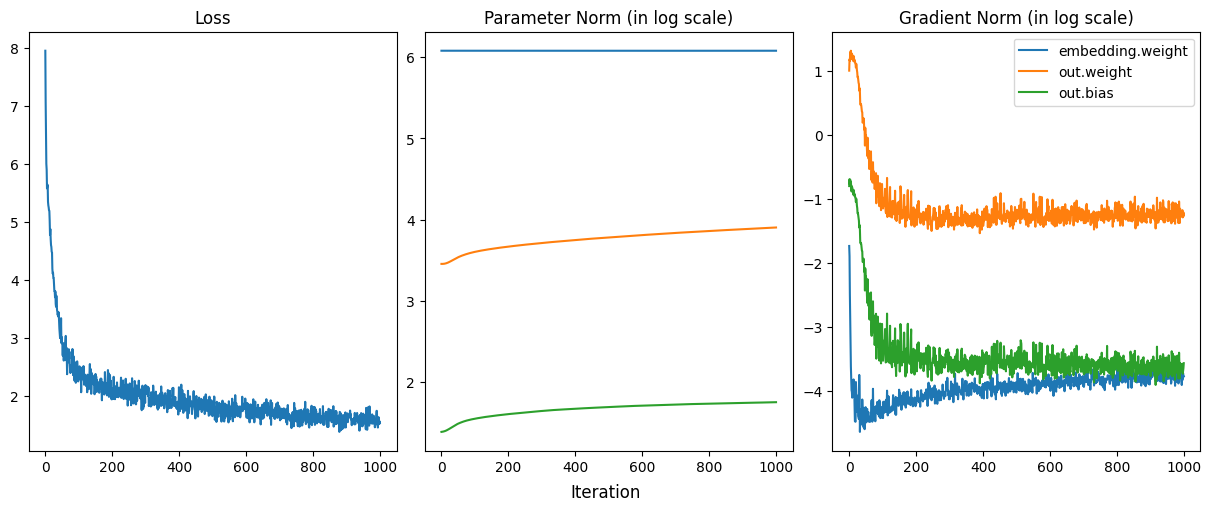

In [6]:
# For data generation
seed = 42
output_dim = 1 # This is 1 for (scalar) regression

# ============================================================
# TODO: Play around with different hyperparameters
# Training hyperparameters
num_iterations = 1000
batch_size = 64

# architecture = "rnn"
architecture = "transformer"

# Model hyperparameters
dropout_p = 0.1

# For RNN (GRU)
hidden_size = 64
num_gru_layers = 2

# For transformer
embed_dim = 64
num_blocks = 4
num_heads = 4

# Instantiate optimizer, can use other optimizer such as Adam, RMSProp, etc.
lr = 1e-3
opt_constructor = torch.optim.Adam
# ============================================================

# Dataset
seq_lang, dataset = data_generator(batch_size, seed)

if architecture == "rnn":
    model = DecoderRNN(
        output_size=len(seq_lang["id2word"]),
        hidden_size=hidden_size,
        num_gru_layers=num_gru_layers,
        dropout_p=dropout_p,
    )
elif architecture == "transformer":
    model = DecoderTransformer(
        output_size=len(seq_lang["id2word"]),
        num_blocks=num_blocks,
        embed_dim=embed_dim,
        num_heads=num_heads,
        dropout_p=dropout_p,
    )
else:
    raise NotImplementedError

model.to(device)

# NOTE: To use L2 regularization, one can use weight_decay in the optimizer.
optimizer = opt_constructor(model.parameters(), lr)

train(dataset(), model, optimizer, num_iterations)

### Evaluate Model
To evaluate, we can look at what kind of sentences the trained model generates

In [7]:
model.eval()

def idxes_to_sentence(lang, word_idxes):
    """ Converts the list of ids into words """
    tokens = []
    for word_idx in word_idxes:
        if word_idx.item() == SOS_TOKEN:
            continue
        if word_idx.item() == EOS_TOKEN:
            tokens.append("<EOS>")
            break
        else:
            tokens.append(lang["id2word"][word_idx.item()])
    return " ".join(tokens)


preds = torch.zeros(
    (batch_size, MAX_LENGTH + 1),
    device=device,
).long()

# Initialize hidden states
if architecture == "rnn":
    decoder_hidden = torch.zeros(
        (
            num_gru_layers,
            batch_size,
            hidden_size,
        ),
        device=device,
    )
elif architecture == "transformer":
    decoder_hidden = {
        "context": torch.zeros(
            (batch_size, MAX_LENGTH),
            device=device,
        ).long(),
        "timestep_i": 0
    }

# NOTE: Here we take a sample at each timestep l.
#       Alternatively, you may take the argmax, i.e., greedy sampling.

greedy_decode = False

decoder_input = torch.empty(
    batch_size,
    1,
    dtype=torch.long,
    device=device
).fill_(SOS_TOKEN)

for timestep_i in range(MAX_LENGTH):
    decoder_output, decoder_hidden = model.forward_step(decoder_input, decoder_hidden)

    if greedy_decode:
        _, top_token = decoder_output.topk(1)
        decoder_input = top_token.squeeze(-1).detach()  # detach from history as input
    else:
        dist = torch.distributions.Categorical(logits=decoder_output)
        sampled_token = dist.sample()
        decoder_input = sampled_token.detach()

    preds[:, [timestep_i]] = decoder_input

for sample_i in range(batch_size):
    print("Prediction: {}".format(idxes_to_sentence(seq_lang, preds[sample_i])))

Prediction: you re early <EOS>
Prediction: you re missing staying my collection <EOS>
Prediction: she s very inclined <EOS>
Prediction: we re dead <EOS>
Prediction: she is watching german you <EOS>
Prediction: you re missing up up to hearing <EOS>
Prediction: he s the advice of my aiming <EOS>
Prediction: they are shivering me today <EOS>
Prediction: he s what i ll come now <EOS>
Prediction: he is a poet <EOS>
Prediction: he s not as an at say <EOS>
Prediction: you re no lunch <EOS>
Prediction: we re getting tired at risk <EOS>
Prediction: i m pleased with me about the news <EOS>
Prediction: they are confused of mathematical <EOS>
Prediction: she s a child <EOS>
Prediction: you re not so prisoner <EOS>
Prediction: i m pretty in the boss player <EOS>
Prediction: we re nuts <EOS>
Prediction: she is almost forward to the traveling <EOS>
Prediction: i m charmed <EOS>
Prediction: you re very tough <EOS>
Prediction: she is putting in english <EOS>
Prediction: they re journalists before <EOS>

What happens if we just let the model generate its outputs conditioning on the correct prefix?

In [8]:
model.eval()

batch = next(dataset())

def idxes_to_sentence(lang, word_idxes):
    """ Converts the list of ids into words """
    tokens = []
    for word_idx in word_idxes:
        if word_idx.item() == EOS_TOKEN:
            tokens.append("<EOS>")
            break
        else:
            tokens.append(lang["id2word"][word_idx.item()])
    return " ".join(tokens)


with torch.no_grad():
    logits = model(batch["input"])

    # NOTE: Here we take the argmax at each step, i.e. greedy sampling
    #       Alternatively, you may sample at each timestep t.
    preds = torch.argmax(logits, axis=-1)

for sample_i in range(batch_size):
    print("Sample {} ================".format(sample_i))
    print("Input: {}".format(idxes_to_sentence(seq_lang, batch["input"][sample_i])))
    print("Prediction: {}".format(idxes_to_sentence(seq_lang, preds[sample_i])))

Sample 0 ================
Input: SOS we re smashed <EOS>
Prediction: i re not <EOS>
Sample 1 ================
Input: SOS they re right behind you <EOS>
Prediction: i re all behind me <EOS>
Sample 2 ================
Input: SOS i m not sure i want the job <EOS>
Prediction: i m not going <EOS>
Sample 3 ================
Input: SOS i m sorry i yelled at you <EOS>
Prediction: i m not i didn at you <EOS>
Sample 4 ================
Input: SOS you re overworked <EOS>
Prediction: i re very <EOS>
Sample 5 ================
Input: SOS i m a musician <EOS>
Prediction: i m not bit <EOS>
Sample 6 ================
Input: SOS you re not married are you ? <EOS>
Prediction: i re very very are you ? <EOS>
Sample 7 ================
Input: SOS we re starved <EOS>
Prediction: i re not <EOS>
Sample 8 ================
Input: SOS i m thirty <EOS>
Prediction: i m not <EOS>
Sample 9 ================
Input: SOS i m not nervous <EOS>
Prediction: i m not going <EOS>
Sample 10 ================
Input: SOS i m ruthless <

The results might look horrible, that is fine! Next exercise will be about building a stronger model---the transformer! But, try changing the model architecture and see if you can do any better!